<a href="https://colab.research.google.com/github/naelisa/FraudDetectionNew/blob/main/FraudDetectionKel13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install streamlit pyngrok imbalanced-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 48.9 MB/s eta 0:00:00


In [9]:
from google.colab import files
uploaded = files.upload()

Saving creditcard_cleaned.csv to creditcard_cleaned (1).csv


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("creditcard_cleaned.csv")
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data training: {X_train.shape}")
print(f"Data testing: {X_test.shape}")
print(f"Jumlah fraud di training: {y_train.sum()}")
print(f"Jumlah fraud di testing: {y_test.sum()}")

Data training: (201632, 30)
Data testing: (50409, 30)
Jumlah fraud di training: 309
Jumlah fraud di testing: 77


Sebelum SMOTE - Class 0: 201323, Class 1: 309
Setelah SMOTE - Class 0: 201323, Class 1: 201323

🔥 RANDOM FOREST

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     50332
           1       0.89      0.88      0.89        77

    accuracy                           1.00     50409
   macro avg       0.95      0.94      0.94     50409
weighted avg       1.00      1.00      1.00     50409



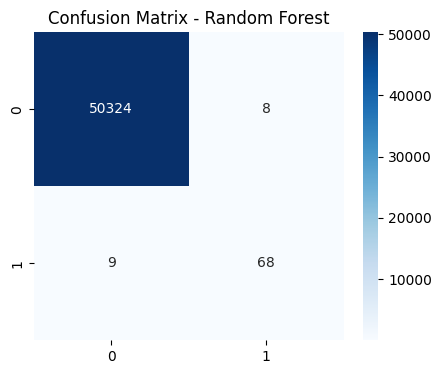


🎯 TOP 20 FEATURE IMPORTANCES - RANDOM FOREST


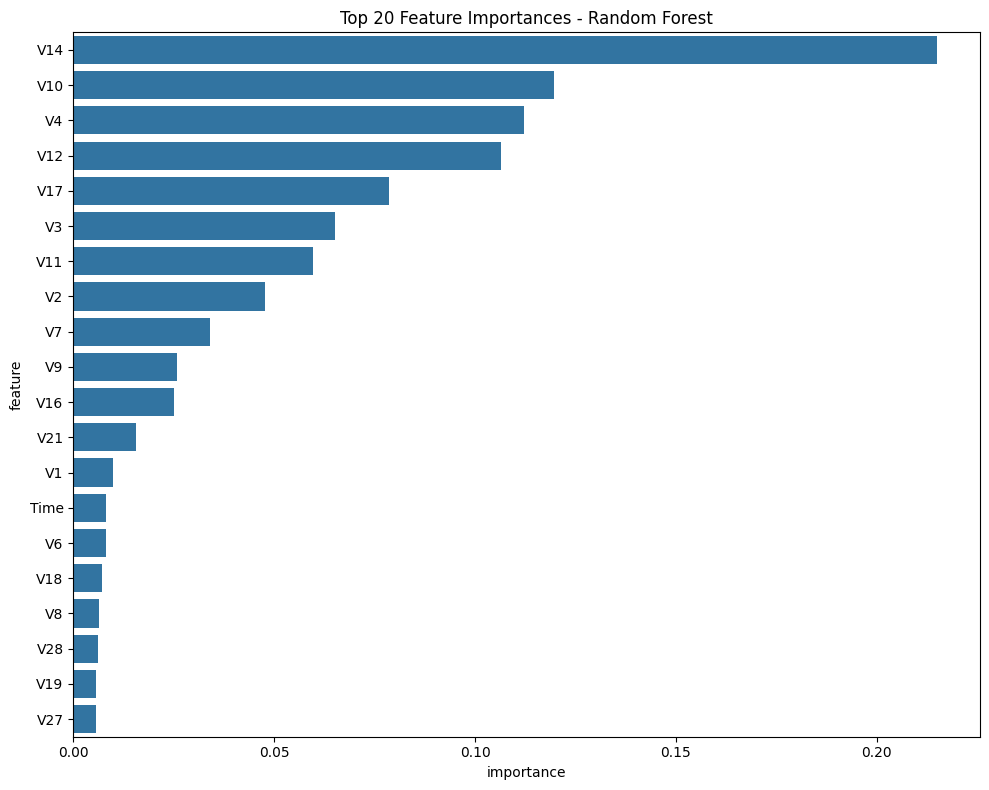


📈 LOGISTIC REGRESSION

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     50332
           1       0.14      0.94      0.25        77

    accuracy                           0.99     50409
   macro avg       0.57      0.96      0.62     50409
weighted avg       1.00      0.99      0.99     50409



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


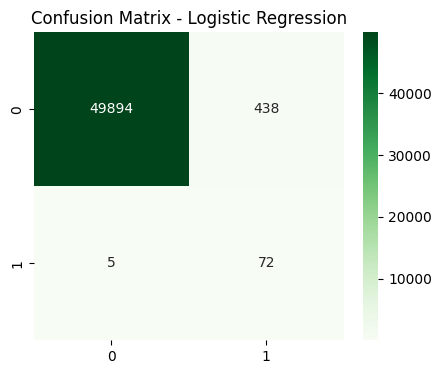


📊 PERBANDINGAN RANDOM FOREST vs LOGISTIC REGRESSION
              Model Accuracy Precision (Fraud) Recall (Fraud) F1-Score (Fraud)
      Random Forest   0.9997            0.8947         0.8831           0.8889
Logistic Regression   0.9912            0.1412         0.9351           0.2453


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ========== SMOTE ==========
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Sebelum SMOTE - Class 0: {(y_train == 0).sum()}, Class 1: {(y_train == 1).sum()}")
print(f"Setelah SMOTE - Class 0: {(y_train_resampled == 0).sum()}, Class 1: {(y_train_resampled == 1).sum()}")

# ========== 1. RANDOM FOREST ==========
print("\n" + "="*60)
print("🔥 RANDOM FOREST")
print("="*60)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix RF
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()

# ========== FEATURE IMPORTANCE ==========
print("\n" + "="*60)
print("🎯 TOP 20 FEATURE IMPORTANCES - RANDOM FOREST")
print("="*60)

importances = rf.feature_importances_
importance_df = pd.DataFrame({'feature': X.columns, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Top 20 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

# ========== 2. LOGISTIC REGRESSION ==========
print("\n" + "="*60)
print("📈 LOGISTIC REGRESSION")
print("="*60)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_resampled, y_train_resampled)
y_pred_lr = lr.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix LR
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# ========== 3. PERBANDINGAN AKHIR ==========
print("\n" + "="*60)
print("📊 PERBANDINGAN RANDOM FOREST vs LOGISTIC REGRESSION")
print("="*60)

comparison = pd.DataFrame([
    {
        'Model': 'Random Forest',
        'Accuracy': f"{accuracy_score(y_test, y_pred_rf):.4f}",
        'Precision (Fraud)': f"{precision_score(y_test, y_pred_rf):.4f}",
        'Recall (Fraud)': f"{recall_score(y_test, y_pred_rf):.4f}",
        'F1-Score (Fraud)': f"{f1_score(y_test, y_pred_rf):.4f}"
    },
    {
        'Model': 'Logistic Regression',
        'Accuracy': f"{accuracy_score(y_test, y_pred_lr):.4f}",
        'Precision (Fraud)': f"{precision_score(y_test, y_pred_lr):.4f}",
        'Recall (Fraud)': f"{recall_score(y_test, y_pred_lr):.4f}",
        'F1-Score (Fraud)': f"{f1_score(y_test, y_pred_lr):.4f}"
    }
])

print(comparison.to_string(index=False))

In [3]:
from google.colab import userdata
from pyngrok import ngrok

# Ambil token dari Colab Secrets
ngrok.set_auth_token(userdata.get('NGROK_AUTH_TOKEN'))
print("✅ Ngrok auth token berhasil di-set!")

✅ Ngrok auth token berhasil di-set!


In [4]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

st.set_page_config(page_title="Fraud Detection Dashboard", layout="wide")
st.title("🔍 Credit Card Fraud Detection Dashboard")

# Load data
@st.cache_data
def load_data():
    df = pd.read_csv("creditcard_cleaned.csv")
    return df

# Train model dengan SMOTE
@st.cache_resource
def train_models(_X_train, _y_train):
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(_X_train, _y_train)

    # Logistic Regression
    lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    lr.fit(X_resampled, y_resampled)

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf.fit(X_resampled, y_resampled)

    return lr, rf

try:
    df = load_data()

    # Sidebar
    st.sidebar.header("⚙️ Settings")
    show_raw_data = st.sidebar.checkbox("Tampilkan Data Mentah")
    test_size = st.sidebar.slider("Test Size", 0.1, 0.4, 0.2)
    selected_model = st.sidebar.selectbox("Pilih Model", ["Random Forest", "Logistic Regression"])

    # Data Overview
    st.subheader("📋 Data Overview")
    col1, col2, col3 = st.columns(3)
    col1.metric("Total Transaksi", f"{len(df):,}")
    col2.metric("Total Fraud", f"{df['Class'].sum():,}")
    col3.metric("Fraud Percentage", f"{(df['Class'].sum()/len(df))*100:.4f}%")

    if show_raw_data:
        st.dataframe(df.head(100))

    # Distribusi
    st.subheader("📊 Distribusi Fraud vs Normal")
    fig1, ax1 = plt.subplots()
    sns.countplot(x='Class', data=df, ax=ax1)
    ax1.set_xticklabels(['Normal', 'Fraud'])
    st.pyplot(fig1)

    # Training & Evaluation
    if st.sidebar.button("Train & Evaluate Model"):
        with st.spinner("Training model dengan SMOTE..."):
            X = df.drop('Class', axis=1)
            y = df['Class']
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

            lr_model, rf_model = train_models(X_train, y_train)

            if selected_model == "Random Forest":
                model = rf_model
                model_name = "Random Forest"
            else:
                model = lr_model
                model_name = "Logistic Regression"

            y_pred = model.predict(X_test)
            y_proba = model.predict_proba(X_test)[:, 1]

            st.subheader(f"📊 Confusion Matrix - {model_name}")
            cm = confusion_matrix(y_test, y_pred)
            fig2, ax2 = plt.subplots()
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2)
            st.pyplot(fig2)

            st.subheader(f"📈 ROC Curve - {model_name}")
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            auc = roc_auc_score(y_test, y_proba)
            fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
            ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
            ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
            ax_roc.set_xlabel('False Positive Rate')
            ax_roc.set_ylabel('True Positive Rate')
            ax_roc.legend(loc="lower right")
            st.pyplot(fig_roc)
            st.metric("AUC Score", f"{auc:.4f}")

            st.subheader(f"📋 Classification Report - {model_name}")
            report = classification_report(y_test, y_pred, output_dict=True)
            st.dataframe(pd.DataFrame(report).transpose())

            # Feature Importance (khusus Random Forest)
            if selected_model == "Random Forest":
                st.subheader("🎯 Feature Importance (Random Forest)")
                importance_df = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
                importance_df = importance_df.sort_values('importance', ascending=False).head(20)
                fig3, ax3 = plt.subplots(figsize=(10, 6))
                sns.barplot(x='importance', y='feature', data=importance_df, ax=ax3)
                st.pyplot(fig3)

            # Perbandingan kedua model
            st.subheader("📊 Perbandingan Random Forest vs Logistic Regression")
            y_pred_rf = rf_model.predict(X_test)
            y_pred_lr = lr_model.predict(X_test)

            comparison = pd.DataFrame([
                {'Model': 'Random Forest', 'Accuracy': f"{accuracy_score(y_test, y_pred_rf):.4f}", 'Precision (Fraud)': f"{precision_score(y_test, y_pred_rf):.4f}", 'Recall (Fraud)': f"{recall_score(y_test, y_pred_rf):.4f}", 'F1-Score (Fraud)': f"{f1_score(y_test, y_pred_rf):.4f}"},
                {'Model': 'Logistic Regression', 'Accuracy': f"{accuracy_score(y_test, y_pred_lr):.4f}", 'Precision (Fraud)': f"{precision_score(y_test, y_pred_lr):.4f}", 'Recall (Fraud)': f"{recall_score(y_test, y_pred_lr):.4f}", 'F1-Score (Fraud)': f"{f1_score(y_test, y_pred_lr):.4f}"}
            ])
            st.dataframe(comparison)

    # Filter data
    fraud_filter = st.radio("Tampilkan:", ["Semua", "Normal Only", "Fraud Only"])
    if fraud_filter == "Normal Only":
        display_df = df[df['Class'] == 0]
    elif fraud_filter == "Fraud Only":
        display_df = df[df['Class'] == 1]
    else:
        display_df = df
    st.dataframe(display_df.head(50))

except FileNotFoundError:
    st.error("❌ File CSV tidak ditemukan! Pastikan file creditcard_cleaned.csv sudah diupload.")
except Exception as e:
    st.error(f"Error: {e}")

Writing app.py


In [5]:
import threading
import time
import subprocess
from pyngrok import ngrok

def run_streamlit():
    subprocess.run(["streamlit", "run", "app.py", "--server.port=8501", "--server.headless=true"])

# Jalankan streamlit di thread terpisah
t = threading.Thread(target=run_streamlit, daemon=True)
t.start()

# Tunggu streamlit siap
time.sleep(5)

# Buat tunnel ngrok ke port 8501
public_url = ngrok.connect(8501)

print("=" * 60)
print(f"✅ Dashboard dapat diakses di: {public_url}")
print("=" * 60)
print("📝 Catatan: Dashboard akan tetap berjalan selama session Colab aktif")

✅ Dashboard dapat diakses di: NgrokTunnel: "https://cathedral-uncurious-sandy.ngrok-free.dev" -> "http://localhost:8501"
📝 Catatan: Dashboard akan tetap berjalan selama session Colab aktif
